In [1]:
import pandas as pd 
import sqlite3
import numpy as np
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
connection=sqlite3.connect('srv.db')

cursor=connection.cursor()

file='fixed_income_case_dataset.xlsx'

sheets={'instrument_master':pd.read_excel(file,sheet_name='instrument_master', skiprows=4),
'positions':pd.read_excel(file,sheet_name='positions', skiprows=4),
'valuation_data':pd.read_excel(file,sheet_name='valuation_data', skiprows=4),
'benchmark_data':pd.read_excel(file,sheet_name='benchmark_data', skiprows=4)
}

# Dato-formating og SQL oprettelse.
for name, df in sheets.items():
    if 'date' in df.columns:
        df['date']=pd.to_datetime(df['date'])
    df.to_sql(name,connection, if_exists="replace", index=False)


In [11]:
validering = {
    "Duplikater i valuation_data (date + instrument_id)": """
        SELECT COUNT(*) FROM (
            SELECT date, instrument_id, COUNT(*) AS n
            FROM   valuation_data
            GROUP BY date, instrument_id
            HAVING n > 1
        )
    """,
    "Duplikater i positions (instrument_id)": """
        SELECT COUNT(*) FROM (
            SELECT instrument_id, COUNT(*) AS n
            FROM   positions
            GROUP BY instrument_id
            HAVING n > 1
        )
    """,
    "Instrument_id i valuation_data uden match i positions": """
        SELECT COUNT(DISTINCT instrument_id)
        FROM   valuation_data
        WHERE  instrument_id NOT IN (SELECT instrument_id FROM positions)
    """,
    "Instrument_id i valuation_data uden match i instrument_master": """
        SELECT COUNT(DISTINCT instrument_id)
        FROM   valuation_data
        WHERE  instrument_id NOT IN (SELECT instrument_id FROM instrument_master)
    """,
    "Datoer i valuation_data uden match i benchmark_data": """
        SELECT COUNT(DISTINCT date)
        FROM   valuation_data
        WHERE  date NOT IN (SELECT date FROM benchmark_data)
    """,
    "Datoer i benchmark_data uden match i valuation_data": """
        SELECT COUNT(DISTINCT date)
        FROM   benchmark_data
        WHERE  date NOT IN (SELECT date FROM valuation_data)
    """,
    "Manglende værdier i valuation_data (nulls)": """
        SELECT COUNT(*) FROM valuation_data
        WHERE  date                        IS NULL
            OR instrument_id               IS NULL
            OR eod_value_dkk_per_unit      IS NULL
            OR daily_price_pnl_dkk_per_unit IS NULL
            OR daily_carry_pnl_dkk_per_unit IS NULL
    """,
}
 
print("            ------------ DATAVALIDERING ------------")
alle_ok = True
for beskrivelse, query in validering.items():
    antal = connection.execute(query).fetchone()[0]
    status = "OK" if antal == 0 else f"ADVARSEL — {antal} fund"
    if antal > 0:
        alle_ok = False
    print(f"  {beskrivelse}: {status}")
 
print(f"\n{'DATA bestået.' if alle_ok else 'Tjek advarsler inden videre analyse.'}")

            ------------ DATAVALIDERING ------------
  Duplikater i valuation_data (date + instrument_id): OK
  Duplikater i positions (instrument_id): OK
  Instrument_id i valuation_data uden match i positions: OK
  Instrument_id i valuation_data uden match i instrument_master: OK
  Datoer i valuation_data uden match i benchmark_data: OK
  Datoer i benchmark_data uden match i valuation_data: OK
  Manglende værdier i valuation_data (nulls): OK

DATA bestået.


In [4]:
# Join nøgler mm.

df = pd.read_sql("""
    SELECT
        v.date,
        v.instrument_id,
        im.instrument_name,
        im.instrument_type,
        im.currency,
        p.quantity,
        v.eod_value_dkk_per_unit,
        v.daily_price_pnl_dkk_per_unit,
        v.daily_carry_pnl_dkk_per_unit,
        v.eod_value_dkk_per_unit * p.quantity AS nav,
        p.quantity * (v.daily_price_pnl_dkk_per_unit + v.daily_carry_pnl_dkk_per_unit) AS pnl
    FROM valuation_data v
    LEFT JOIN positions p 
        ON v.instrument_id = p.instrument_id
    LEFT JOIN instrument_master im 
        ON v.instrument_id = im.instrument_id
""", connection, parse_dates=["date"])
 
benchmark = pd.read_sql("""
    SELECT date, benchmark_daily_return AS daglig_afkast
    FROM   benchmark_data
""", connection, parse_dates=["date"]).set_index("date")

In [5]:
# funktion for Risikomål.

def beregn_risikomål(daglig_afkast, risiko_fri_rente, antal_handelsdage):
    vol          = daglig_afkast.std()*np.sqrt(antal_handelsdage)
    daglig_mean  = daglig_afkast.mean()
    ann_afkast   = (1 + daglig_mean)**antal_handelsdage - 1
    sharpe       = (ann_afkast - risiko_fri_rente) / vol
    kum          = (1 + daglig_afkast).cumprod() - 1
    peak         = (1 + kum).cummax()
    max_drawdown = ((1 + kum)/peak - 1).min()
    return {'annualiseret_afkast': ann_afkast, 'annualiseret_vol': vol,
            'sharpe': sharpe, 'max_drawdown': max_drawdown}

In [6]:
# centrale beregninger.

antal_handelsdage=252
risiko_fri_rente=0.015
antal_præsterede_handelsdage=df['date'].nunique()

df['NAV']=df['eod_value_dkk_per_unit']*df['quantity']
df['PnL']=df['quantity']*(df['daily_price_pnl_dkk_per_unit']+df['daily_carry_pnl_dkk_per_unit'])

# oprettelse af hoved portoføljen.
port=df.groupby('date')[['NAV','PnL']].sum().sort_index()
port['daglig_afkast'] = port['PnL'] / port['NAV'].shift(1)
port.iloc[0, port.columns.get_loc('daglig_afkast')] = 0
port['kumulativt_afkast'] = (1 + port['daglig_afkast']).cumprod() - 1
port['peak'] = (1 + port['kumulativt_afkast']).cummax()
port['drawdown'] = (1 + port['kumulativt_afkast']) / port['peak'] - 1

port_mål = beregn_risikomål(port['daglig_afkast'], risiko_fri_rente, antal_handelsdage)
annual_vol    = port_mål['annualiseret_vol']
annual_return = port_mål['annualiseret_afkast']
sharpe        = port_mål['sharpe']
max_drawdown  = port_mål['max_drawdown']


#beregninger for benchmark
benchmark['kumulativt_afkast'] = (1 + benchmark['daglig_afkast']).cumprod() - 1
benchmark['peak'] = (1 + benchmark['kumulativt_afkast']).cummax()
benchmark['drawdown'] = (1 + benchmark['kumulativt_afkast']) / benchmark['peak'] - 1

bench_mål = beregn_risikomål(benchmark['daglig_afkast'], risiko_fri_rente, antal_handelsdage)
benchmark_annual_vol    = bench_mål['annualiseret_vol']
benchmark_annual_return = bench_mål['annualiseret_afkast']
benchmark_sharpe        = bench_mål['sharpe']
benchmark_max_drawdown  = bench_mål['max_drawdown']

#benchmark = benchmark.set_index('date')

In [7]:

date_start=port.index.min().strftime('%d-%m-%Y')
date_end=port.index.max().strftime('%d-%m-%Y')


tabel = pd.DataFrame({
    'Portefølje': [f'{annual_return:.2%}', f'{annual_vol:.2%}', f'{sharpe:.2f}',
                   f'{max_drawdown:.2%}', f'{port["kumulativt_afkast"].iloc[-1]:.2%}'],
    'Benchmark':  [f'{benchmark_annual_return:.2%}', f'{benchmark_annual_vol:.2%}',
                   f'{benchmark_sharpe:.2f}', f'{benchmark_max_drawdown:.2%}',
                   f'{benchmark["kumulativt_afkast"].iloc[-1]:.2%}']
}, index=['Annualiseret afkast','Annualiseret volatilitet','Sharpe ratio',
          'Max drawdown','Kumulativt afkast ({} - {})'.format(date_start,date_end)])
print(tabel.to_string())

                                            Portefølje Benchmark
Annualiseret afkast                              5.16%     1.45%
Annualiseret volatilitet                         2.67%     0.98%
Sharpe ratio                                      1.37     -0.05
Max drawdown                                    -0.86%    -0.28%
Kumulativt afkast (02-01-2025 - 31-03-2025)      1.26%     0.36%


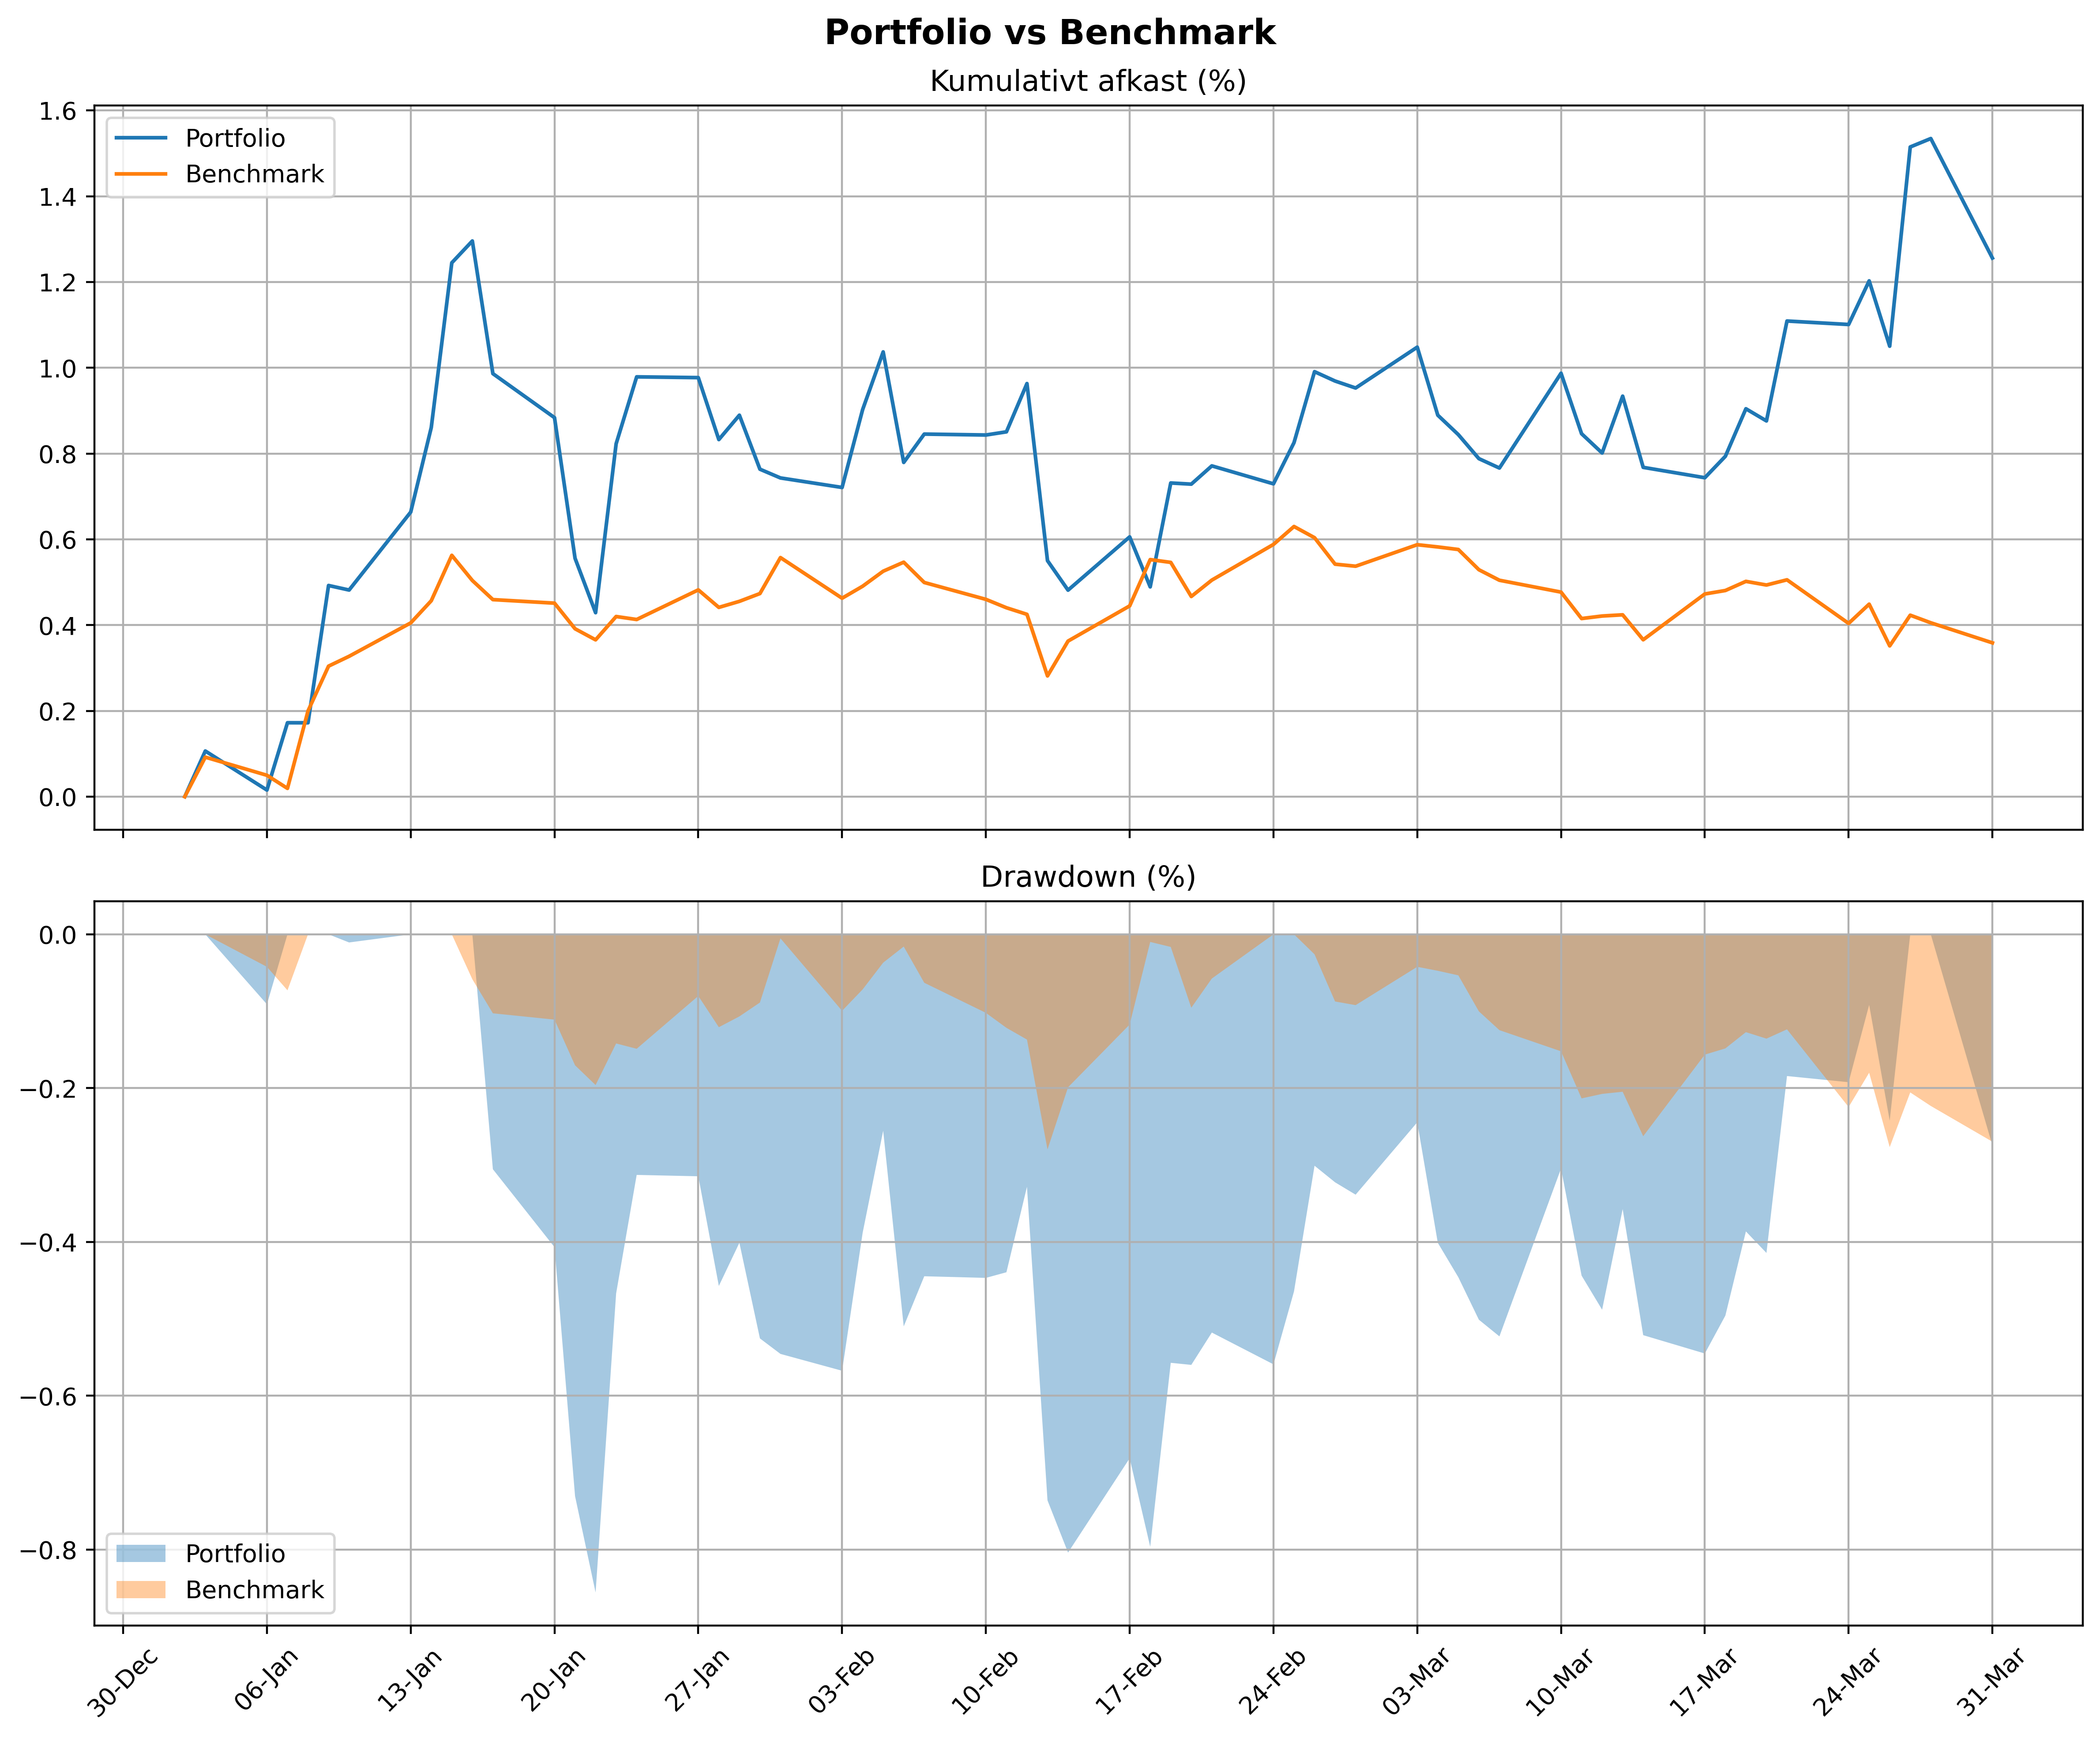

In [8]:
fig1, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True, dpi=400)
fig1.suptitle('Portfolio vs Benchmark', fontsize=14, fontweight='bold')

axes[0].plot(port.index, port['kumulativt_afkast'] * 100, label='Portfolio')
axes[0].plot(benchmark.index, benchmark['kumulativt_afkast'] * 100, label='Benchmark')
axes[0].set_title('Kumulativt afkast (%)'); axes[0].legend(); axes[0].grid(True)

axes[1].fill_between(port.index, port['drawdown'] * 100, 0, label='Portfolio', alpha=0.4)
axes[1].fill_between(benchmark.index, benchmark['drawdown'] * 100, 0, label='Benchmark', alpha=0.4)
axes[1].set_title('Drawdown (%)'); axes[1].legend(); axes[1].grid(True)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.xticks(rotation=45)
plt.tight_layout()
# Figuren gemmes.  
#fig.savefig("Portfolio vs Benchmark", dpi=300, bbox_inches="tight")
plt.show()

instrument_type
Swap       -153,077 DKK
Future      122,162 DKK
Bond      3,181,501 DKK


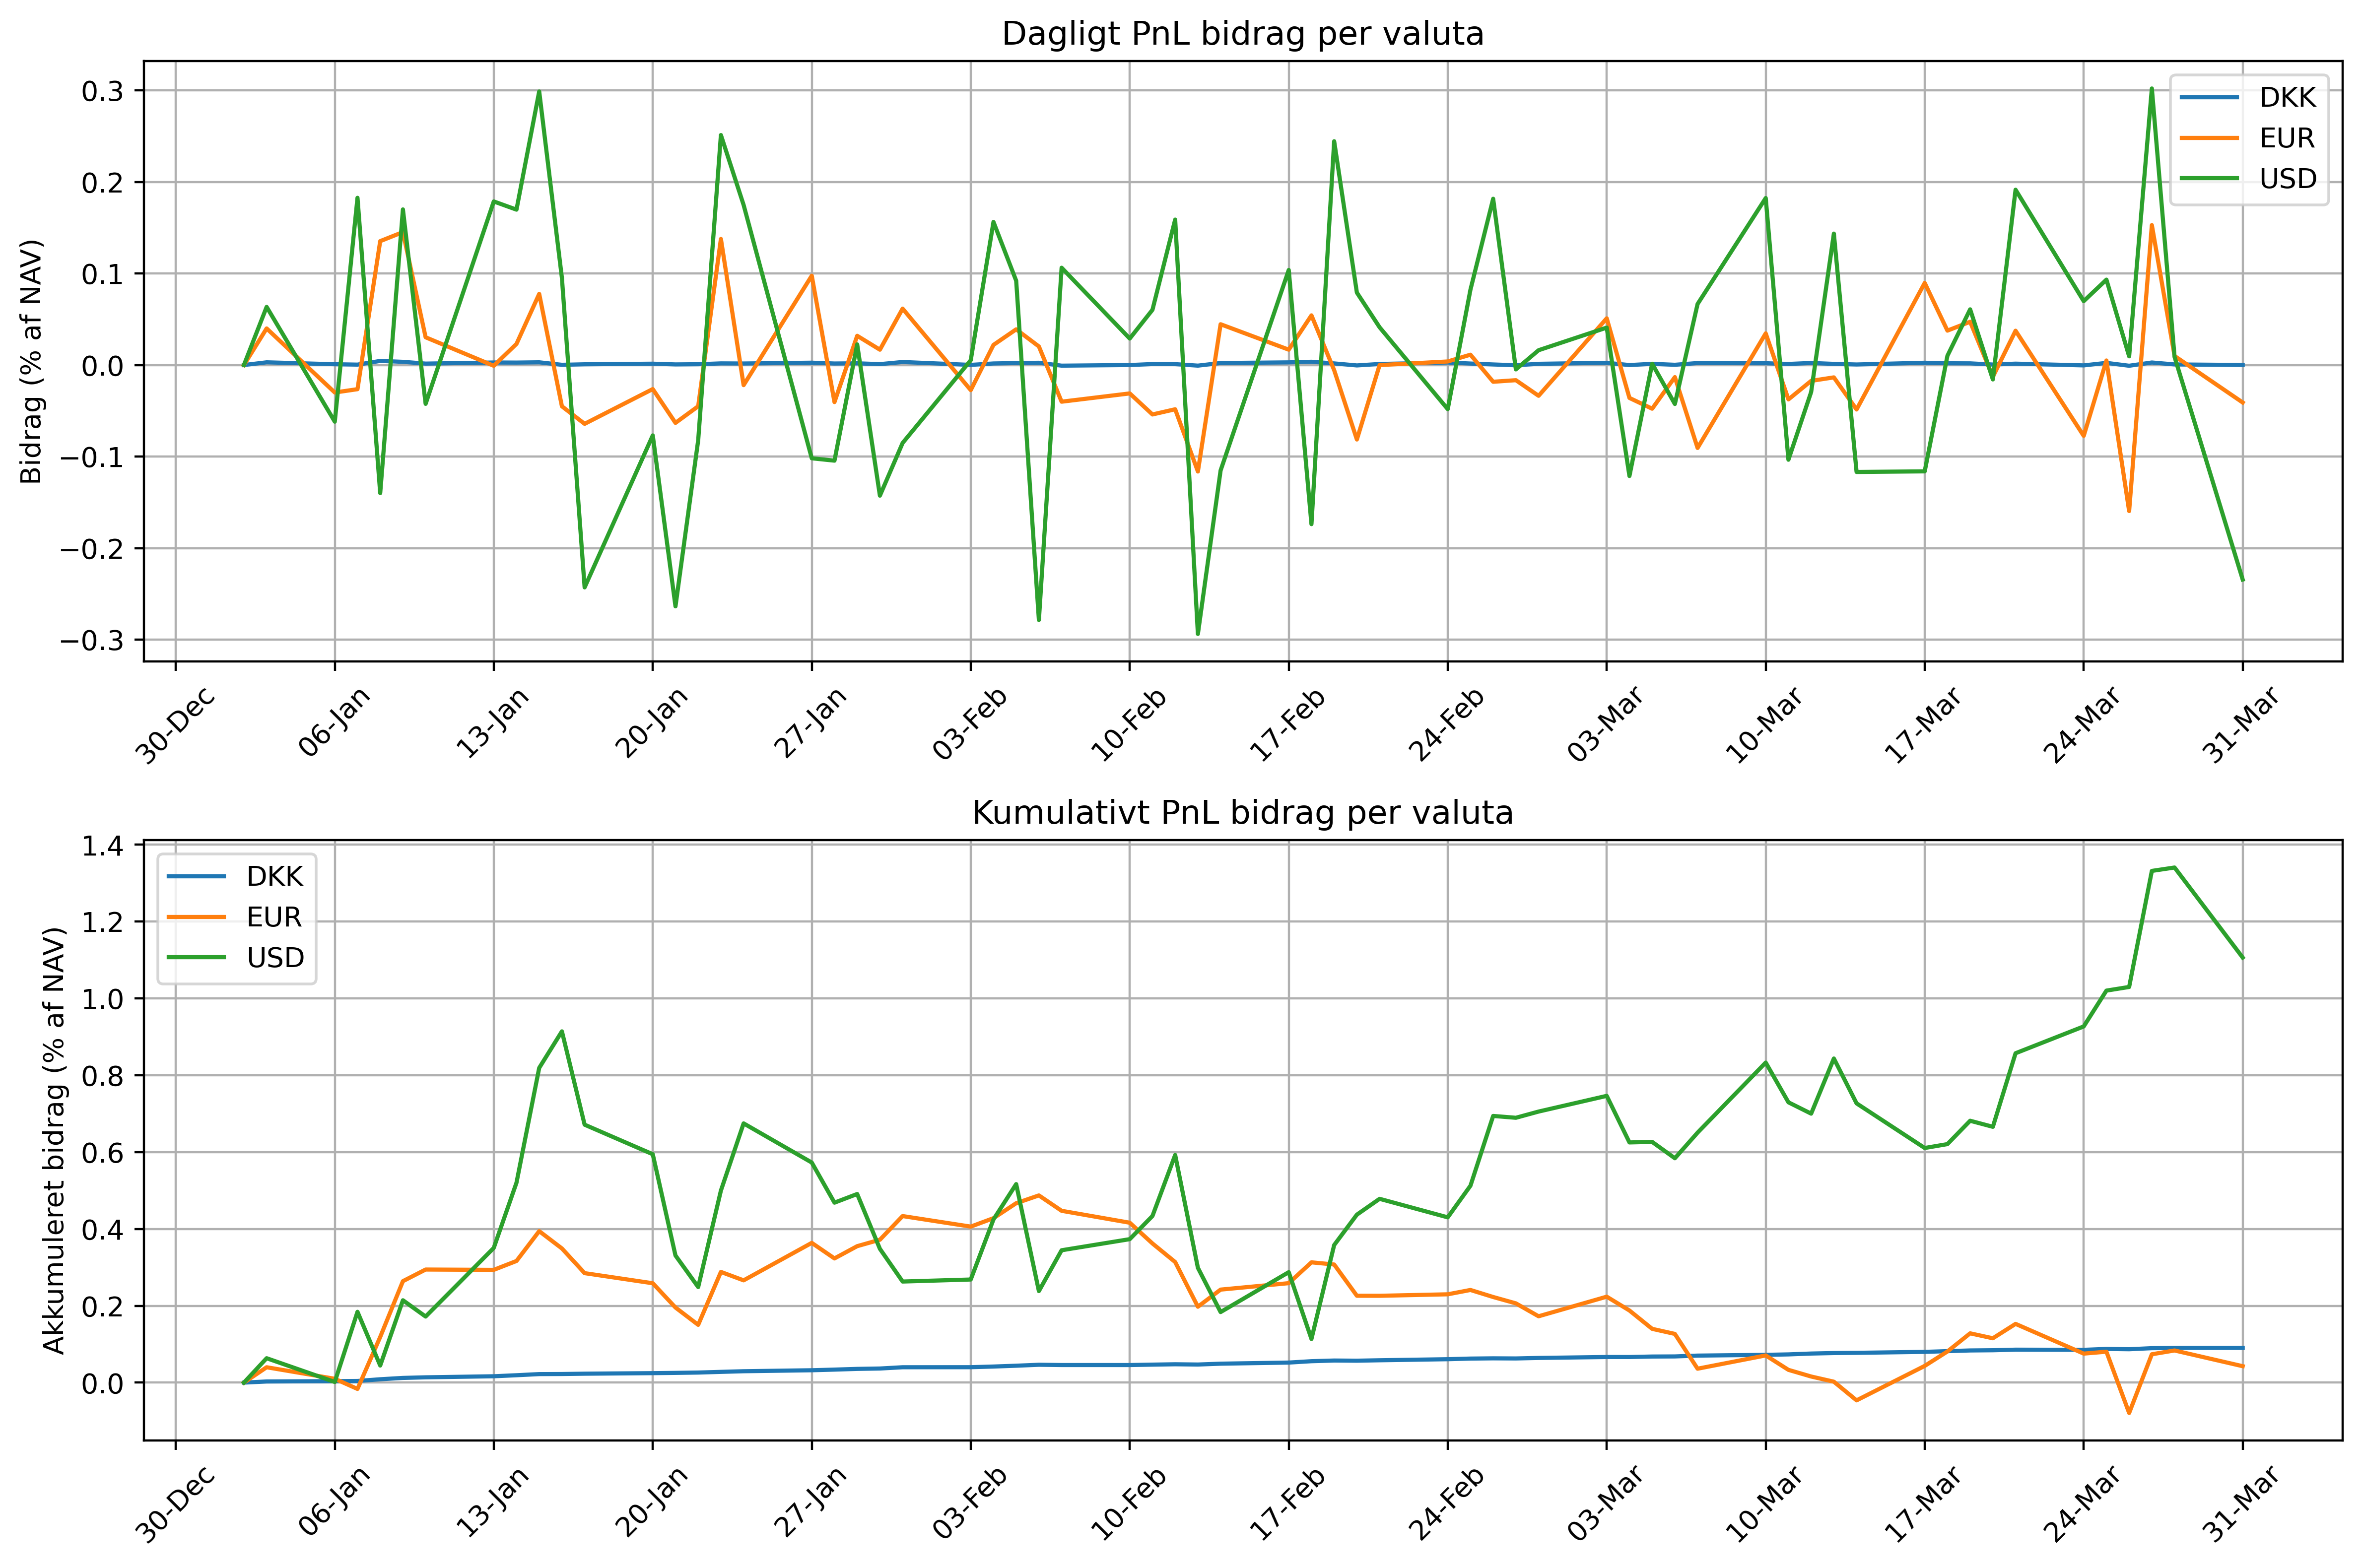

In [9]:
# Attributter.

# PnL fordelt på instrumenter.
pnl_per_type = df.groupby('instrument_type')['PnL'].sum().sort_values()
print(pnl_per_type.apply(lambda x: f'{x:,.0f} DKK').to_string())

# Bidrag til samlet PnL per valuta
nav_daglig = port['NAV']

pnl_per_currency_daily = pd.read_sql("""
    SELECT
        v.date,
        im.currency,
        SUM(p.quantity * (v.daily_price_pnl_dkk_per_unit + v.daily_carry_pnl_dkk_per_unit)) AS PnL
    FROM valuation_data v
    LEFT JOIN positions p
        ON v.instrument_id = p.instrument_id
    LEFT JOIN instrument_master im
        ON v.instrument_id = im.instrument_id
    GROUP BY v.date, im.currency
""", connection, parse_dates=["date"])

# Long → wide. 
pnl_per_currency_daily = (
    pnl_per_currency_daily
    .pivot(index='date', columns='currency', values='PnL')
    .fillna(0)
)

pnl_pct = pnl_per_currency_daily.div(nav_daglig, axis=0) * 100
kum_pct = pnl_pct.cumsum()

fig2, axes = plt.subplots(2, 1, figsize=(12, 8), dpi=400)

for currency in pnl_pct.columns:
    axes[0].plot(pnl_pct.index, pnl_pct[currency], label=currency)
axes[0].set_title('Dagligt PnL bidrag per valuta')
axes[0].set_ylabel('Bidrag (% af NAV)')
axes[0].legend()
axes[0].grid(True)

for currency in kum_pct.columns:
    axes[1].plot(kum_pct.index, kum_pct[currency], label=currency)
axes[1].set_title('Kumulativt PnL bidrag per valuta')
axes[1].set_ylabel('Akkumuleret bidrag (% af NAV)')
axes[1].legend()
axes[1].grid(True)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

#fig.savefig("valuta_attribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
# Oprettelse af hele rapporten. Bemærk pakkerne.

from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak, HRFlowable
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import cm
import io

# Hjælpefunktion (billedoprettelse)
def fig_to_image(fig, width=16*cm):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    fig_w, fig_h = fig.get_size_inches()
    height = width * (fig_h / fig_w)
    return Image(buf, width=width, height=height)

# Styles 
normal = ParagraphStyle('normal', fontName='Helvetica',      fontSize=9,  leading=14, textColor=colors.HexColor('#333333'))
small  = ParagraphStyle('small',  fontName='Helvetica',      fontSize=8,  leading=12, textColor=colors.HexColor('#666666'))
h1     = ParagraphStyle('h1',     fontName='Helvetica-Bold', fontSize=14, leading=18, textColor=colors.HexColor('#1a1a1a'), spaceAfter=4)
h2     = ParagraphStyle('h2',     fontName='Helvetica-Bold', fontSize=10, leading=14, textColor=colors.HexColor('#1a1a1a'), spaceBefore=10, spaceAfter=4)

# Byg PDF 
doc   = SimpleDocTemplate('performance_rapport.pdf', pagesize=A4,
                           leftMargin=2.2*cm, rightMargin=2.2*cm,
                           topMargin=2*cm,    bottomMargin=2*cm)
story = []

# Titel
story.append(Paragraph("Performance Rapport", h1))
story.append(Paragraph(f"Periode: {date_start} – {date_end} &nbsp;|&nbsp; {len(port)} handelsdage", small))
story.append(HRFlowable(width='100%', thickness=0.5, color=colors.HexColor('#CCCCCC'), spaceAfter=10))

# Nøgletaltabel(Risici).
story.append(Paragraph("Nøgletal", h2))
tabel_data = [['', 'Portefølje', 'Benchmark']] + \
             [[idx, row['Portefølje'], row['Benchmark']] for idx, row in tabel.iterrows()]
pdf_tabel = Table(tabel_data, colWidths=[9.5*cm, 3*cm, 3*cm])
pdf_tabel.setStyle(TableStyle([
    ('FONTNAME',       (0, 0), (-1,  0), 'Helvetica-Bold'),
    ('FONTSIZE',       (0, 0), (-1, -1), 9),
    ('LINEBELOW',      (0, 0), (-1,  0), 0.8, colors.HexColor('#333333')),
    ('LINEBELOW',      (0,-1), (-1, -1), 0.5, colors.HexColor('#CCCCCC')),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#F7F7F7')]),
    ('LEFTPADDING',    (0, 0), (-1, -1), 4),
    ('RIGHTPADDING',   (0, 0), (-1, -1), 4),
    ('TOPPADDING',     (0, 0), (-1, -1), 5),
    ('BOTTOMPADDING',  (0, 0), (-1, -1), 5),
]))
story.append(pdf_tabel)
story.append(Spacer(1, 0.6*cm))

# Figur 1: Portfolio vs Benchmark
story.append(Paragraph("Portfolio vs. Benchmark", h2))
story.append(fig_to_image(fig1, width=16*cm))
story.append(Paragraph(
    # Evt. Beskrivelse af graf 1
    "",
    small
))
story.append(Spacer(1, 0.5*cm))

# Figur 2: Valuta attribution
story.append(PageBreak())
story.append(Paragraph("Valuta Attribution", h2))
story.append(fig_to_image(fig2, width=16*cm))
story.append(Paragraph(
    # Evt. Beskrivelse af graf 2
    "",
    small
))

# PnL attribution. 

    # Formatér data til tabel
pnl_table_data = [['Instrument Type', 'PnL (DKK)']] + [
    [idx, f"{val:,.0f}"]
    for idx, val in pnl_per_type.items()
]

pnl_pdf_table = Table(pnl_table_data, colWidths=[10*cm, 5*cm])

pnl_pdf_table.setStyle(TableStyle([
    ('FONTNAME',       (0, 0), (-1,  0), 'Helvetica-Bold'),
    ('FONTSIZE',       (0, 0), (-1, -1), 9),
    ('LINEBELOW',      (0, 0), (-1,  0), 0.8, colors.HexColor('#333333')),
    ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.white, colors.HexColor('#F7F7F7')]),
    ('ALIGN',          (1, 1), (1, -1), 'RIGHT'),
])) 
# indsættelse af tabellen.
story.append(Paragraph("PnL Attribution per Instrument Type", h2))
story.append(pnl_pdf_table)
story.append(Spacer(1, 1.3*cm))



# Konklusion
story.append(Paragraph("Konklusion", h2))
story.append(HRFlowable(width='100%', thickness=0.5, color=colors.HexColor('#CCCCCC'), spaceAfter=8))
story.append(Paragraph(
    #Selve Konklusion
    """Porteføljen realiserede et kumulativt afkast på 1,26 % mod 0,36 % for benchmark, svarende til et annualiseret afkast på 5,16 % mod 1,45 %. Det bemærkes, at perioden kun omfatter 63 handelsdage, hvorfor det annualiserede afkast skal fortolkes med forbehold, da det forudsætter en kontinuerlig udvikling.
Porteføljen udviser en annualiseret volatilitet på 2,67 % mod 0,98 % for benchmark samt et maksimalt drawdown på -0,86 % mod -0,28 %, hvilket afspejler en højere risikoprofil. En Sharpe-ratio på 1,37 mod -0.05 for benchmark indikerer dog, at det realiserede afkast mere end kompenserer for den øgede risiko.
Afkastet er primært genereret af obligationspositioner (PnL: 3.181.501 DKK), efterfulgt af futures (PnL: 122.162 DKK), mens swaps bidrog negativt (PnL: -153.077 DKK). På valutaniveau er afkastet hovedsageligt drevet af USD-eksponering, som bidrager med 1,1 % af NAV ved periodens afslutning. EUR-positionerne bidrog positivt tidligt i perioden, men fladede ud mod nul, mens DKK forblev omtrent neutral gennem hele perioden. USD-bidraget er volatilt med markante tilbagefald i januar og februar, hvilket indikerer følsomhed over for amerikanske rentebevægelser.

""",
    normal
))

doc.build(story)
print("✓ Rapport gemt: performance_rapport.pdf")

✓ Rapport gemt: performance_rapport.pdf
